In [1]:
import h5py
import numpy as np
import pandas as pd
import math
import os

def find_path_to_key(h5_obj, target_key, path=""):
    for key in h5_obj.keys():
        new_path = f"{path}/{key}"
        if key == target_key:
            return new_path
        if isinstance(h5_obj[key], h5py.Group):
            result = find_path_to_key(h5_obj[key], target_key, new_path)
            if result is not None:
                return result
    return None


def load_funct_1_4(filepath):
    with h5py.File(filepath, "r") as f:
        struct_path = find_path_to_key(f, "StructData")
        if struct_path is None:
            raise KeyError("Could not find 'StructData' in MAT file.")

        struct_group = f[struct_path]

        if "func" not in struct_group:
            raise KeyError("'func' not found inside StructData.")

        func = struct_group["func"]

        # MATLAB {1,4} -> Python func[3][0]
        ref_1_4 = func[3][0]
        arr = f[ref_1_4][()]  # Dereference dataset
        
        return np.array(arr.T).squeeze()


def combine_results(mat_file, csv_file, output_file="combined_results_with_accel.csv"):
    logTotAccelBA = load_funct_1_4(mat_file)
    #print(pd.DataFrame(logTotAccelBA))
    # ---- NEW: average every 60 samples ----
    exp_data = np.exp(logTotAccelBA)

    if len(exp_data) % 60 != 0:
        raise ValueError("Length of funct{1,4} is not divisible by 60.")

    averaged = exp_data.reshape(-1, 60).mean(axis=1)

    df = pd.read_csv(csv_file)

    if len(df) != len(averaged):
        raise ValueError(
            f"CSV rows ({len(df)}) do not match averaged func length ({len(averaged)})."
        )

    df["TotAccelBA"] = averaged

    df.to_csv(output_file, index=False)
    print("Saved:", output_file)
    return df



In [2]:
Cluster_detail_results = pd.read_csv( os.path.join(r'Y:\Members\Mia-Sanjana-Hadent\Processed Data\wildtype_062425_011725_9\Altogether Clustering\Cluster_detail_results.csv') )
filename = r"Y:\Members\Mia-Sanjana-Hadent\Processed Data\wildtype_062425_011725_9\Altogether Clustering\session_1_out.mat"
filename_groups = r'Y:\Members\Mia-Sanjana-Hadent\Processed Data\wildtype_062425_011725_9\Altogether Clustering\cluster_groups_matlab.csv'
combined = r'Y:\Members\Mia-Sanjana-Hadent\Visualizations\Output_wildtype_test\data\combined_matrix_wildtype.csv'

df_updated = combine_results(
    filename,
    combined
)

df_updated


Saved: combined_results_with_accel.csv


,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,...,Feature26,Feature27,Feature28,Feature29,Feature30,Timestamp,Cluster,Week_Number,Group,TotAccelBA
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.00,...,0.266667,0.200000,0.000000,0.000000,1.000000,117.2237,1,5,3,0.451181
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.25,0.75,...,0.100000,0.216667,0.400000,0.000000,1.000000,117.5240,1,5,3,0.512063
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,0.00,...,0.300000,0.016667,0.000000,0.000000,1.000000,117.8243,1,5,3,0.458873
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,0.00,...,0.116667,0.050000,0.083333,0.000000,1.000000,118.1247,1,5,3,0.409755
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,0.00,...,0.550000,0.116667,0.066667,0.016667,0.983333,118.7253,1,5,3,0.350652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.00,...,0.116667,0.000000,0.000000,1.000000,0.000000,41031.1065,54,1,20,0.007230
119223,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.00,...,0.183333,0.000000,0.000000,1.000000,0.000000,41031.4715,54,1,20,0.006123
119224,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.00,...,0.133333,0.000000,0.000000,1.000000,0.000000,41031.8065,54,1,20,0.005355
119225,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.00,...,0.333333,0.000000,0.000000,1.000000,0.000000,41032.1515,54,1,20,0.007532


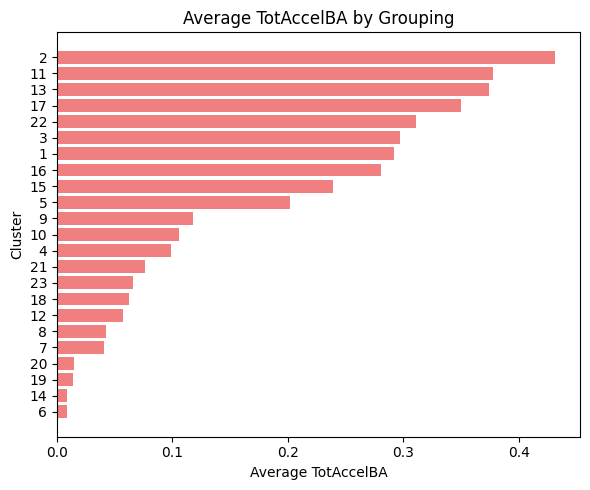

In [3]:
import matplotlib.pyplot as plt

#df_sorted = df_updated.sort_values(by="TotAccelBA", ascending=False)
cluster_means = df_updated.groupby("Group")["TotAccelBA"].mean()
cluster_means.index = cluster_means.index.astype(int)
cluster_means = cluster_means.sort_values(ascending=True)  # small → large

plt.figure(figsize=(6, 5))
plt.barh(cluster_means.index.astype(str), cluster_means.values, color="lightcoral")
plt.xlabel("Average TotAccelBA")
plt.ylabel("Cluster")
plt.title("Average TotAccelBA by Grouping")
plt.tight_layout()
plt.show()

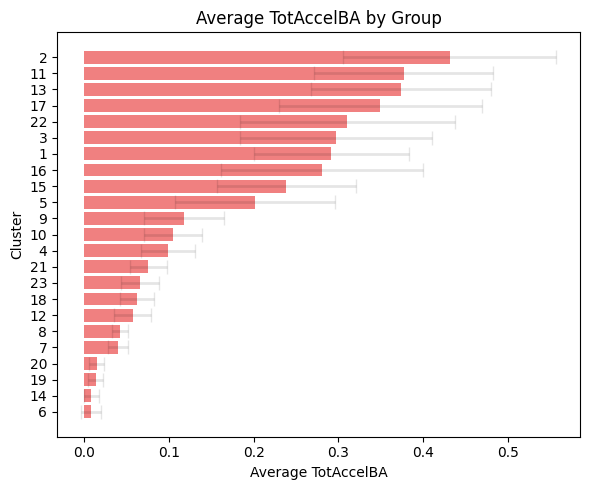

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

save_dir = os.path.join(r'D:\from desktop\Hadents Folder\Visualization\Output_test\graphs', 'tot_accel')
os.makedirs(save_dir, exist_ok=True)

# Group by Cluster and calculate mean and std
cluster_stats = df_updated.groupby("Group")["TotAccelBA"].agg(['mean', 'std'])
cluster_stats.index = cluster_stats.index.astype(int)
cluster_stats = cluster_stats.sort_values(by="mean", ascending=True)  # ascending for barh

# Horizontal bar plot with transparent std error bars
plt.figure(figsize=(6, 5))
plt.barh(
    cluster_stats.index.astype(str),
    cluster_stats['mean'],
    xerr=cluster_stats['std'],
    color='lightcoral',
    error_kw=dict(elinewidth=2, ecolor='black', alpha=0.1),  # make error bars semi-transparent
    capsize=5
)

plt.xlabel("Average TotAccelBA")
plt.ylabel("Cluster")
plt.title("Average TotAccelBA by Group")
plt.tight_layout()

plt.savefig(os.path.join(save_dir, "tot_accel_by_cluster.png"), dpi=300, bbox_inches="tight")

plt.show()


In [12]:
# Compute stats
week8 = df_updated[df_updated["Week_Number"] == 1].groupby("Cluster")["TotAccelBA"].agg(["mean", "std"])
week10 = df_updated[df_updated["Week_Number"] == 2].groupby("Cluster")["TotAccelBA"].agg(["mean", "std"])
week12 = df_updated[df_updated["Week_Number"] == 3].groupby("Cluster")["TotAccelBA"].agg(["mean", "std"])
week14 = df_updated[df_updated["Week_Number"] == 4].groupby("Cluster")["TotAccelBA"].agg(["mean", "std"])
week18 = df_updated[df_updated["Week_Number"] == 5].groupby("Cluster")["TotAccelBA"].agg(["mean", "std"])

# Align indexes
clusters = sorted(set(week8.index) | set(week10.index) | set(week12.index) | set(week14.index) | set(week18.index))
week8 = week8.reindex(clusters).reset_index()
week10 = week10.reindex(clusters).reset_index()
week12 = week12.reindex(clusters).reset_index()
week14 = week14.reindex(clusters).reset_index()
week18 = week18.reindex(clusters).reset_index()


In [ ]:
week8_sorted = week8.sort_values(by="mean", na_position='first', ascending=True)
week10_sorted = week10.set_index("Cluster").loc[week8_sorted["Cluster"]].reset_index()

clusters = week8_sorted["Cluster"]
week8_means = week8_sorted["mean"]
week8_stds  = week8_sorted["std"]

week10_means = week10_sorted["mean"]
week10_stds  = week10_sorted["std"]



ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (102,) and arg 3 with shape (97,).

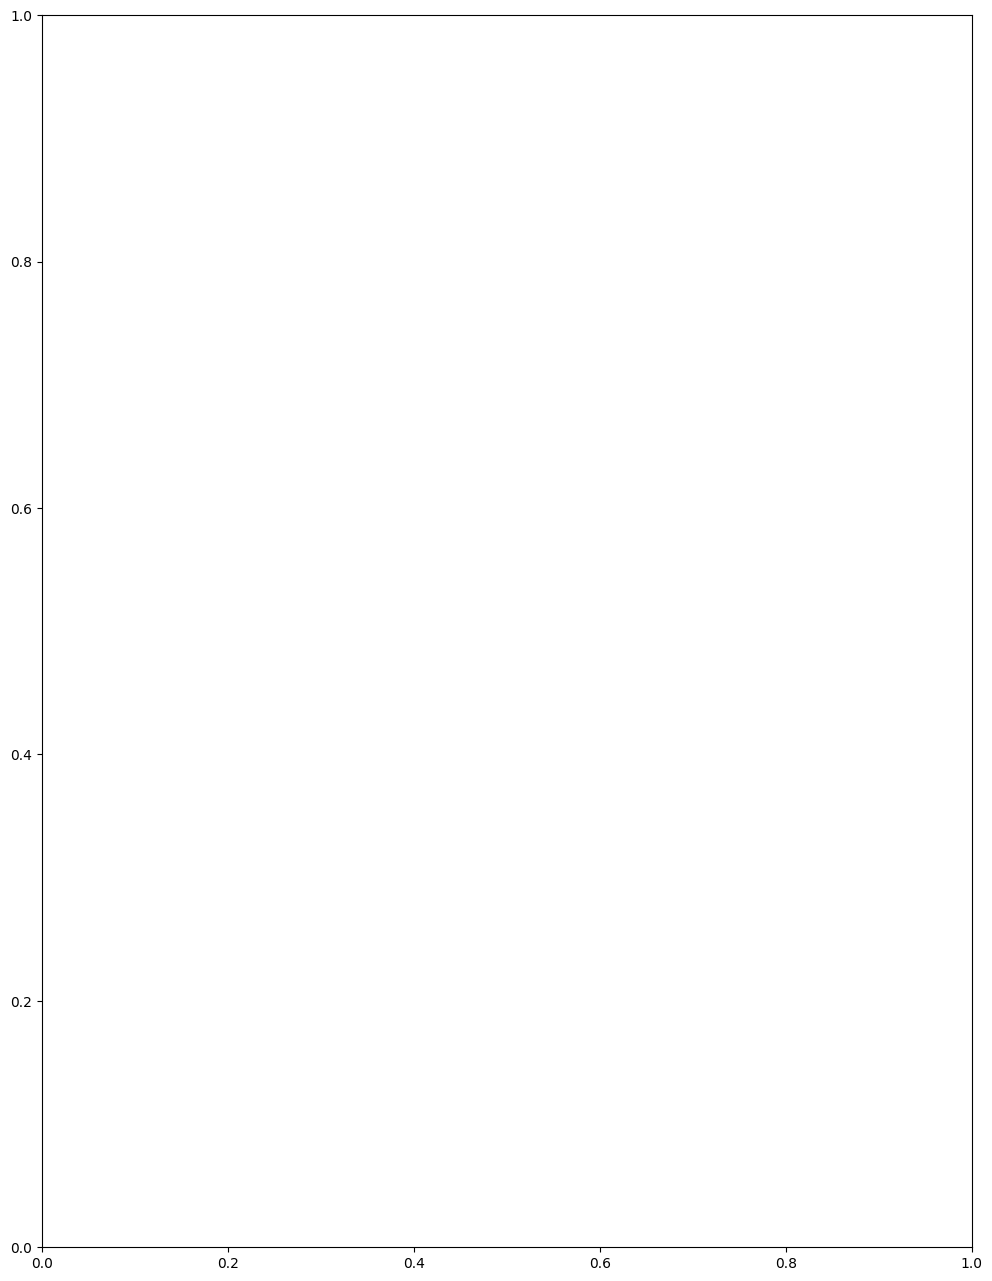

In [177]:
y = np.arange(len(clusters))
save_dir = os.path.join(r'D:\from desktop\Hadents Folder\Visualization\Output_test\graphs', 'tot_accel')
plt.figure(figsize=(12, 16))

# Week 8 on the LEFT → negate
plt.barh(y, -week8_means, xerr=week8_stds, height=0.4, label="Stage 1", color='skyblue', error_kw=dict(elinewidth=2, ecolor='black', alpha=0.1))

# Week 10 on the RIGHT
plt.barh(y, week10_means, xerr=week10_stds, height=0.4, label="Stage 2", color='lightcoral', error_kw=dict(elinewidth=2, ecolor='black', alpha=0.1))

plt.axvline(0, color="black", linewidth=1)

plt.yticks(y, clusters)
plt.xlabel("TotAccelBA")
plt.ylabel("Cluster")
plt.title("Diverging TotAccelBA: Stage 1 vs Stage 2")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "tot_accel_1vs2.png"), dpi=300, bbox_inches="tight")
plt.show()


In [79]:
# -------------------- Cluster Level Char --------------------
## Calculate time spent in each cluster - Start Time, End Time, Duration, Cluster, Folder Name
def extract_bouts(df):
    df = df.reset_index(drop=True)
    change = df['Cluster'] != df['Cluster'].shift()
    starts = df.index[change]
    ends = list(starts[1:]) + [len(df)-1]

    bout_data = []
    for start, end in zip(starts, ends):
        duration = df.loc[end, 'Timestamp'] - df.loc[start, 'Timestamp'] + 1
        bout_data.append({
            'start_timestamp': df.loc[start, 'Timestamp'],
            'end_timestamp': df.loc[end, 'Timestamp'],
            'duration': duration,
            'Cluster': df.loc[start, 'Cluster'],
            'Week_Number': df.loc[start, 'Week_Number']
        })
    return pd.DataFrame(bout_data)

In [80]:
# -------------------- Cluster Level Char --------------------
def plot_week_vs_week(g, stage_left=8, stage_right=12, ax=None,
                      color_left='#d3d3d3', color_right='#f08080'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 6))

    base = g[g['Week_Number'] == stage_left].copy()
    base = base.sort_values('pct', ascending=False)
    clusters = base['Cluster'].to_numpy()

    left = base.set_index('Cluster').loc[clusters, 'pct'].fillna(0)
    left = -left

    right_week = g[g['Week_Number'] == stage_right]
    right = right_week.groupby('Cluster')['duration'].sum()
    right = right / right.sum() * 100
    right = right.reindex(clusters).fillna(0)

    y = np.arange(len(clusters))

    ax.barh(y, left,  color=color_left,  height=0.8, label=f'Stage {stage_left}')
    ax.barh(y, right, color=color_right, height=0.8, label=f'Stage {stage_right}')

    ax.set_yticks(y)
    ax.set_yticklabels(clusters)
    ax.invert_yaxis()
    ax.axvline(0, color='black', lw=1)

    lim = max(right.max(), (-left).max())
    ax.set_xlim(-lim, lim)

    xticks = ax.get_xticks()
    ax.set_xticks(xticks)
    ax.set_xticklabels([abs(int(t)) for t in xticks])

    ax.set_xlabel('% of time per cluster')
    ax.set_ylabel('Cluster #')
    ax.tick_params(axis='y', labelsize=5)

    ax.legend(frameon=False, loc='lower right')

    return ax

KeyError: 'Column not found: duration'

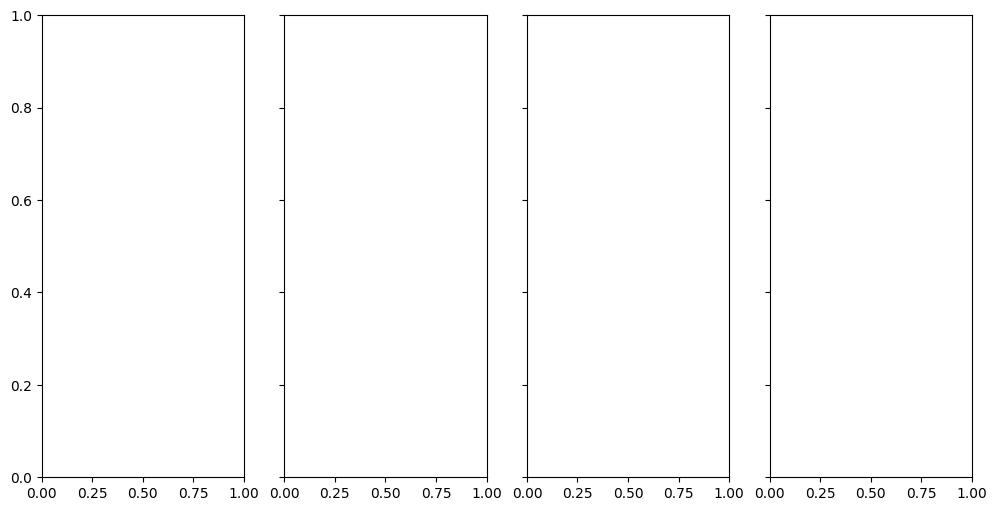

In [ ]:
bout_duration_pct = bout_duration_df.groupby(['Week_Number', 'Cluster'], as_index=False)['duration'].sum()

bout_duration_pct['pct'] = bout_duration_pct.groupby('Week_Number')['duration'].transform(
    lambda x: x / x.sum() * 100
)
bout_duration_pct

stages_right = [2, 3, 4, 5]
fig, axes = plt.subplots(1, len(stages_right),
                         figsize=(3*len(stages_right), 6),
                         sharey=True)

for ax, w in zip(axes, stages_right):
    plot_week_vs_week(bout_duration_pct, stage_left=1, stage_right=w, ax=ax)
    ax.set_title(f'Stage 1 vs {w}')

plt.tight_layout()

png_path = os.path.join(png_dir, "stage_vs_stage.png")
plt.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "stage_vs_stage.eps")
plt.savefig(eps_path)
print(f"Saved: {eps_path}")

plt.show()


In [13]:
import matplotlib.ticker as mticker

def plot_mirrored_week_comparison(week8, week10, ax=None, color_left='skyblue', color_right='lightcoral', secondary_label="Stage y"):
    
    # Make axis if needed
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 12))

    # ---- Sort by Week 8 mean (ascending or descending)
    week8_sorted = week8.sort_values(by="mean", ascending=True, na_position="first")
    clusters = week8_sorted["Cluster"].to_numpy()

    # ---- Align Week 10 rows to the same cluster order
    week10_aligned = (
        week10.set_index("Cluster")
              .reindex(clusters)   # keeps missing clusters as NaN
              .reset_index()
    )

    # ========== LEFT SIDE (Week 8) ==========
    left_means = -week8_sorted["mean"].fillna(0).to_numpy()
    left_stds  = week8_sorted["std"].fillna(0).to_numpy()

    # ========== RIGHT SIDE (Week 10) ==========
    right_means = week10_aligned["mean"].fillna(0).to_numpy()
    right_stds  = week10_aligned["std"].fillna(0).to_numpy()

    # y-axis positions
    y = np.arange(len(clusters))
    clusters_int = [int(c) if not pd.isna(c) else "" for c in clusters]
    ax.set_yticklabels(clusters_int)

    
    # ---- Draw bars
    ax.barh(
        y, left_means,
        color=color_left,
        height=0.8,
        label="Stage 1",
        xerr=left_stds,
        alpha=0.7,
        error_kw=dict(elinewidth=2, ecolor='black', alpha=0.1)
    )

    ax.barh(
        y, right_means,
        color=color_right,
        height=0.8,
        label=secondary_label,
        xerr=right_stds,
        alpha=0.7,
        error_kw=dict(elinewidth=2, ecolor='black', alpha=0.1)
    )

    # ---- Y Labels
    ax.set_yticks(y)
    ax.set_yticklabels(clusters_int)
    ax.tick_params(axis='y', labelsize=8)
    ax.invert_yaxis()   # top = highest value

    # ---- Zero line
    ax.axvline(0, color="black", lw=1)

    # ---- Symmetric X limits including error bars ----
    left_max  = np.nanmax(np.abs(left_means)  + left_stds)
    right_max = np.nanmax(np.abs(right_means) + right_stds)

    lim = max(left_max, right_max) * 1.05   # small padding (5%)

    ax.set_xlim(-lim, lim)


    # ---- Mirror x-axis tick labels (absolute values)
    xticks = ax.get_xticks()
    ax.set_xticklabels([f"{abs(t):.1f}" for t in xticks])

    # ---- Grid
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    # ---- Labels and legend
    ax.set_xlabel("Mean Total Accel")
    ax.set_ylabel("Cluster")
    ax.legend(frameon=False, loc="lower right")

    return ax


C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_32780\798414258.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(clusters_int)
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_32780\798414258.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{abs(t):.1f}" for t in xticks])
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_32780\798414258.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{abs(t):.1f}" for t in xticks])
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_32780\798414258.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{abs(t):.1f}"

Saved: D:\from desktop\Hadents Folder\Visualization\Output_test\graphs\tot_accel\tot_accel_comparison.png


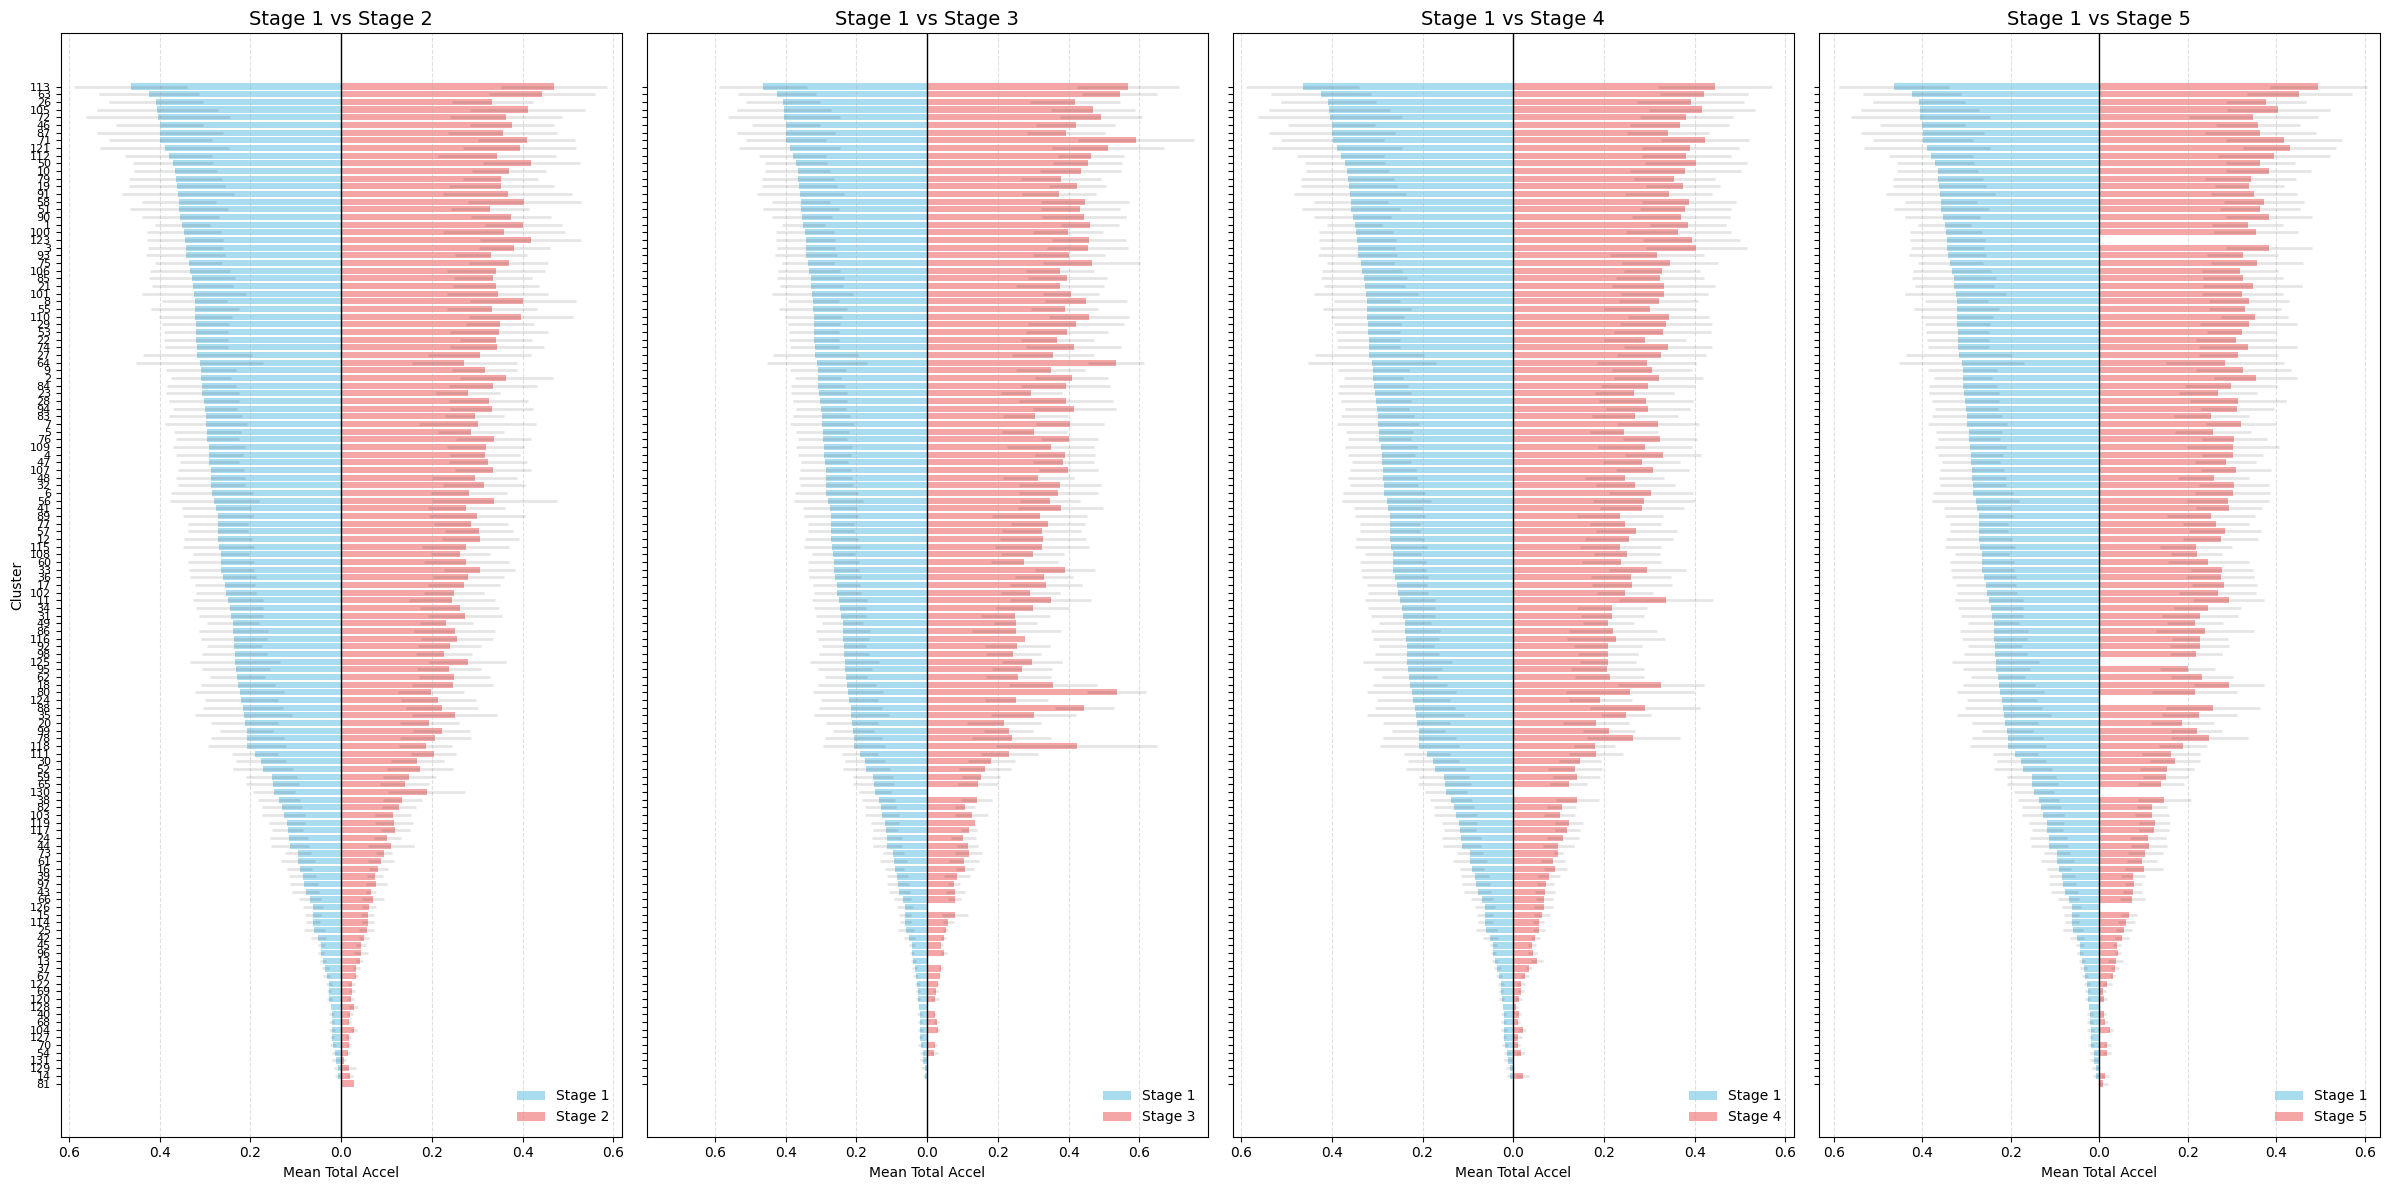

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(24, 12), sharey=True)

plot_mirrored_week_comparison(week8,  week10,  ax=axes[0] , secondary_label="Stage 2")
plot_mirrored_week_comparison(week8, week12, ax=axes[1], secondary_label="Stage 3")
plot_mirrored_week_comparison(week8, week14, ax=axes[2], secondary_label="Stage 4")
plot_mirrored_week_comparison(week8, week18, ax=axes[3], secondary_label="Stage 5")

axes[0].set_ylabel("Cluster")      # only first plot has y-axis label
for ax in axes[1:]:
    ax.set_ylabel("")              # clear label so it doesn't repeat

titles = ["Stage 1 vs Stage 2", "Stage 1 vs Stage 3", "Stage 1 vs Stage 4", "Stage 1 vs Stage 5"]
for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=14)

plt.tight_layout()
save_dir = os.path.join(r'D:\from desktop\Hadents Folder\Visualization\Output_test\graphs', 'tot_accel')
os.makedirs(save_dir, exist_ok=True)
png_path = os.path.join(save_dir, "tot_accel_comparison.png")
plt.savefig(png_path, dpi=300, bbox_inches="tight")
print(f"Saved: {png_path}")
plt.show()



In [149]:
bout_duration_pct = bout_duration_df.groupby(['Week_Number', 'Cluster'], as_index=False)['duration'].sum()

bout_duration_pct['pct'] = bout_duration_pct.groupby('Week_Number')['duration'].transform(
    lambda x: x / x.sum() * 100
)
bout_duration_pct

stages_right = [2, 3, 4, 5]
fig, axes = plt.subplots(1, len(stages_right),
                         figsize=(3*len(stages_right), 6),
                         sharey=True)

for ax, w in zip(axes, stages_right):
    plot_week_vs_week(bout_duration_pct, stage_left=1, stage_right=w, ax=ax)
    ax.set_title(f'Stage 1 vs {w}')

plt.tight_layout()

png_path = os.path.join(png_dir, "stage_vs_stage.png")
plt.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "stage_vs_stage.eps")
plt.savefig(eps_path)
print(f"Saved: {eps_path}")

plt.show()


NameError: name 'bout_duration_df' is not defined